In [1]:
from pathlib import Path
import json
import sys

import pandas as pd

PROJECT_ROOT = next(
    directory for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (directory / "src" / "market_data.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from market_data import capture_uk_market_snapshot

# Run All replays these saved inputs without any network requests.
# Set True only when intentionally recapturing ALL inputs (1,000+ requests).
REFRESH_DOWNLOADS = False
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SAVED_INPUTS = {
    "market": RAW_DIR / "revolut_uk_20260919T002345_437090Z",
    "catalogue": RAW_DIR / "coinbase_products_20260919T002348_603485Z.json",
    "probes": RAW_DIR / "coinbase_probes_20260919T002348_629615Z",
    "coverage": RAW_DIR / "coinbase_coverage_20260919T002422_650607Z",
    # The newer 19 September history attempt stopped early; use this complete batch.
    "history": RAW_DIR / "coinbase_coverage_20260918T183827_526442Z",
    "fx": RAW_DIR / "ecb_gbp_usd_20260918T185616_488505Z.json",
}

if not REFRESH_DOWNLOADS:
    required_files = [
        *(SAVED_INPUTS["market"] / name for name in ("pairs.json", "currencies.json", "tickers.json")),
        SAVED_INPUTS["catalogue"],
        SAVED_INPUTS["probes"] / "coverage_report.csv",
        SAVED_INPUTS["coverage"] / "coverage_report.csv",
        SAVED_INPUTS["history"] / "coverage_report.csv",
        SAVED_INPUTS["history"] / "download_spec.json",
        SAVED_INPUTS["fx"],
    ]
    missing_files = [str(path) for path in required_files if not path.is_file()]
    if missing_files:
        raise FileNotFoundError(
            "Saved research inputs are missing; restore them or update SAVED_INPUTS. "
            "No automatic download will be attempted.\n" + "\n".join(missing_files)
        )


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
if REFRESH_DOWNLOADS:
    snapshot_dir = capture_uk_market_snapshot(RAW_DIR)
else:
    snapshot_dir = SAVED_INPUTS["market"]
pair_snapshot = json.loads((snapshot_dir / "pairs.json").read_text(encoding="utf-8"))
pairs = pd.DataFrame.from_dict(pair_snapshot["payload"], orient="index",).rename_axis("symbol")

display(pairs.groupby(["quote", "status"]).size().rename("pair_count").to_frame())
print(f"Snapshot: {snapshot_dir}")

,,pair_count
quote,status,
GBP,active,64
USD,active,307
USDC,active,23


Snapshot: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/data/raw/revolut_uk_20260919T002345_437090Z


In [3]:
from universe import build_gbp_inventory

SCOPE_EXCLUSIONS = {
    "USDC": "stablecoin",
    "USDT": "stablecoin",
    "PAXG": "gold-backed token",
    "XAUT": "gold-backed token",
}

inventory = build_gbp_inventory(
    snapshot_dir=snapshot_dir,
    scope_exclusions=SCOPE_EXCLUSIONS,
)

display(
    inventory[
        [
            "currency_name",
            "spread_bps",
            "quote_volume_24h",
            "min_order_size_quote",
            "passes_initial_screen",
            "scope_exclusion",
            "snapshot_issues",
        ]
    ].style.format({
        "spread_bps": "{:.2f}",
        "quote_volume_24h": "£{:,.0f}",
    })
)

display(pd.Series({
    "GBP_pairs": len(inventory),
    "pairs_with_snapshot_issues": inventory["snapshot_issues"].ne("").sum(),
    "scope_exclusions": inventory["scope_exclusion"].ne("").sum(),
    "passing_initial_screen": inventory["passes_initial_screen"].sum(),
}))

,currency_name,spread_bps,quote_volume_24h,min_order_size_quote,passes_initial_screen,scope_exclusion,snapshot_issues
symbol,,,,,,,
BTC/GBP,Bitcoin,5.86,"£5,098,555",0.1,True,,
ETH/GBP,Ethereum,6.10,"£4,771,638",0.1,True,,
XRP/GBP,Ripple,10.51,"£2,253,320",0.1,True,,
SOL/GBP,Solana,6.05,"£1,232,392",0.1,True,,
NEAR/GBP,NEAR Protocol,25.16,"£679,032",0.1,True,,
LINK/GBP,Chainlink,13.07,"£495,993",0.1,True,,
AVAX/GBP,Avalanche,16.24,"£323,665",0.1,True,,
FET/GBP,Fetch.ai,36.06,"£257,757",0.1,True,,
SUI/GBP,Sui,24.44,"£226,496",0.1,True,,


GBP_pairs                     64
pairs_with_snapshot_issues     0
scope_exclusions               4
passing_initial_screen        60
dtype: int64

In [4]:
import importlib
import market_data
import universe

importlib.reload(market_data)
importlib.reload(universe)

if REFRESH_DOWNLOADS:
    coinbase_products, catalogue_path = market_data.capture_coinbase_products(RAW_DIR)
else:
    catalogue_path = SAVED_INPUTS["catalogue"]
    catalogue_record = json.loads(catalogue_path.read_text(encoding="utf-8"))
    if catalogue_record["source"] != "coinbase_exchange" or catalogue_record["http_status"] != 200:
        raise ValueError("Expected a successful saved Coinbase catalogue.")
    coinbase_products = catalogue_record["payload"]

product_mapping = universe.map_coinbase_products(
    inventory,
    coinbase_products,
)

display(product_mapping)

display(pd.Series({
    "candidates": len(product_mapping),
    "GBP_products_listed": product_mapping["gbp_product"].notna().sum(),
    "GBP_products_online": product_mapping["gbp_status"].eq("online").sum(),
    "USD_products_listed": product_mapping["usd_product"].notna().sum(),
    "USD_products_online": product_mapping["usd_status"].eq("online").sum(),
    "no_catalogue_match": product_mapping["no_catalogue_match"].sum(),
}))

print(f"Catalogue: {catalogue_path}")

,base,currency_name,gbp_product,gbp_status,usd_product,usd_status,no_catalogue_match
symbol,,,,,,,
1INCH/GBP,1INCH,1inch Network,1INCH-GBP,online,1INCH-USD,online,False
AAVE/GBP,AAVE,Aave,AAVE-GBP,online,AAVE-USD,online,False
ADA/GBP,ADA,Cardano,ADA-GBP,online,ADA-USD,online,False
ALGO/GBP,ALGO,Algorand,ALGO-GBP,online,ALGO-USD,online,False
APT/GBP,APT,Aptos,NaN,NaN,APT-USD,online,False
ARB/GBP,ARB,Arbitrum,NaN,NaN,ARB-USD,online,False
ATOM/GBP,ATOM,Cosmos,ATOM-GBP,online,ATOM-USD,online,False
AVAX/GBP,AVAX,Avalanche,NaN,NaN,AVAX-USD,online,False
AVNT/GBP,AVNT,Avantis,NaN,NaN,AVNT-USD,online,False


candidates             60
GBP_products_listed    21
GBP_products_online    19
USD_products_listed    59
USD_products_online    59
no_catalogue_match      1
dtype: int64

Catalogue: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/data/raw/coinbase_products_20260919T002348_603485Z.json


In [5]:
import time
import history

importlib.reload(history)

PROBE_PRODUCTS = [
    "BTC-GBP", "BTC-USD",
    "SOL-GBP", "SOL-USD",
    "RENDER-USD", "POL-USD",
]

PROBE_WINDOWS = {
    "2019-01": ("2019-01-01", "2019-02-01"),
    "2022-01": ("2022-01-01", "2022-02-01"),
    "2025-01": ("2025-01-01", "2025-02-01"),
    "2026-08": ("2026-08-01", "2026-09-01"),
}

known_products = set(
    product_mapping[["gbp_product", "usd_product"]].stack()
)
assert set(PROBE_PRODUCTS).issubset(known_products)

if REFRESH_DOWNLOADS:
    probe_dir = PROJECT_ROOT / "data" / "raw" / (
        "coinbase_probes_"
        + pd.Timestamp.now(tz="UTC").strftime("%Y%m%dT%H%M%S_%fZ")
    )

    probe_rows = []
    for product in PROBE_PRODUCTS:
        for sample, (start, end) in PROBE_WINDOWS.items():
            row = history.probe_coinbase_daily(
                product_id=product,
                start=pd.Timestamp(start, tz="UTC"),
                end=pd.Timestamp(end, tz="UTC"),
                raw_data_dir=probe_dir,
            )
            row["sample"] = sample
            probe_rows.append(row)

            if row["http_status"] == 429:
                raise RuntimeError(
                    f"Rate limited. Stop and inspect {row['raw_path']}"
                )

            time.sleep(1.1)

        print(f"Completed: {product}")

    probe_report = pd.DataFrame(probe_rows)
    probe_report.to_csv(probe_dir / "coverage_report.csv", index=False)
else:
    probe_dir = SAVED_INPUTS["probes"]
    probe_report = pd.read_csv(probe_dir / "coverage_report.csv")

for column in ("requested_start", "requested_end", "first_timestamp", "last_timestamp"):
    probe_report[column] = pd.to_datetime(probe_report[column], utc=True)
print(f"Probe report: {probe_dir}")


Probe report: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/data/raw/coinbase_probes_20260919T002348_629615Z


In [6]:
display(probe_report.reindex(columns=[
        "product_id",
        "sample",
        "outcome",
        "http_status",
        "expected_days",
        "rows_in_window",
        "missing_days",
        "duplicate_timestamps",
        "off_midnight_rows",
        "excluded_rows",
    ]).set_index(["product_id", "sample"]))

outcome  http_status  expected_days  rows_in_window  \
product_id sample                                                        
BTC-GBP    2019-01      ok          200             31              31   
           2022-01      ok          200             31              31   
           2025-01      ok          200             31              31   
           2026-08      ok          200             31              31   
BTC-USD    2019-01      ok          200             31              31   
           2022-01      ok          200             31              31   
           2025-01      ok          200             31              31   
           2026-08      ok          200             31              31   
SOL-GBP    2019-01      ok          200             31               0   
           2022-01      ok          200             31              31   
           2025-01      ok          200             31              31   
           2026-08      ok          200             31              31   
SOL-USD    2019-01      ok          200             31               0   
           2022-01      ok          200             31              31   
           2025-01      ok          200             31              31   
           2026-08      ok          200             31              31   
RENDER-USD 2019-01      ok          200             31               0   
           2022-01      ok          200             31               0   
           2025-01      ok          200             31              31   
           2026-08      ok          200             31              31   
POL-USD    2019-01      ok          200             31               0   
           2022-01      ok          200             31               0   
           2025-01      ok          200             31              31   
           2026-08      ok          200             31              31   

                    missing_days  duplicate_timestamps  off_midnight_rows  \
product_id sample                                                           
BTC-GBP    2019-01             0                     0                  0   
           2022-01             0                     0                  0   
           2025-01             0                     0                  0   
           2026-08             0                     0                  0   
BTC-USD    2019-01             0                     0                  0   
           2022-01             0                     0                  0   
           2025-01             0                     0                  0   
           2026-08             0                     0                  0   
SOL-GBP    2019-01            31                     0                  0   
           2022-01             0                     0                  0   
           2025-01             0                     0                  0   
           2026-08             0                     0                  0   
SOL-USD    2019-01            31                     0                  0   
           2022-01             0                     0                  0   
           2025-01             0                     0                  0   
           2026-08             0                     0                  0   
RENDER-USD 2019-01            31                     0                  0   
           2022-01            31                     0                  0   
           2025-01             0                     0                  0   
           2026-08             0                     0                  0   
POL-USD    2019-01            31                     0                  0   
           2022-01            31                     0                  0   
           2025-01             0                     0                  0   
           2026-08             0                     0                  0   

                    excluded_rows  
product_id sample                  
BTC-GBP    2019-01 

In [7]:
importlib.reload(history)
all_products = sorted(set(product_mapping[["gbp_product", "usd_product"]].stack()))

#confirm initial six-product grid is fully represented
initial_grid = pd.MultiIndex.from_product([PROBE_PRODUCTS, list(PROBE_WINDOWS)], names=["product_id", "sample"])
initial_report = probe_report.set_index(["product_id", "sample"])

assert initial_report.index.is_unique
assert initial_grid.difference(initial_report.index).empty

remaining_products = [product for product in all_products if product not in PROBE_PRODUCTS]
if REFRESH_DOWNLOADS:
    additional_report, coverage_dir = history.run_history_probes(product_ids=remaining_products, windows=PROBE_WINDOWS, raw_data_dir=PROJECT_ROOT / "data" / "raw")
    coverage_report = pd.concat([probe_report, additional_report], ignore_index=True)
    coverage_report.to_csv(coverage_dir / "combined_coverage_report.csv", index=False)
else:
    coverage_dir = SAVED_INPUTS["coverage"]
    additional_report = pd.read_csv(coverage_dir / "coverage_report.csv")
    for column in ("requested_start", "requested_end", "first_timestamp", "last_timestamp"):
        additional_report[column] = pd.to_datetime(additional_report[column], utc=True)
    coverage_report = pd.concat([probe_report, additional_report], ignore_index=True)
print(f"Coverage report: {coverage_dir}")


Coverage report: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/data/raw/coinbase_coverage_20260919T002422_650607Z


In [8]:
expected_grid = pd.MultiIndex.from_product([all_products, list(PROBE_WINDOWS)], names=["product_id", "sample"])
actual_grid = coverage_report.set_index(["product_id", "sample"]).index

assert actual_grid.is_unique
assert expected_grid.difference(actual_grid).empty, ("The batch stopped early. Inspect its saved report before continuing.")
coverage_report["quote"] = (coverage_report["product_id"].str.rsplit("-", n=1).str[-1])
coverage_report["complete_window"] = (
    coverage_report["outcome"].eq("ok")
    & coverage_report["rows_in_window"].eq(coverage_report["expected_days"])
    & coverage_report["missing_days"].eq(0)
    & coverage_report["duplicate_timestamps"].eq(0)
    & coverage_report["off_midnight_rows"].eq(0)
)

display(coverage_report.groupby(["sample", "quote"])["complete_window"].agg(attempted="size", complete_windows="sum"))
display(coverage_report.loc[coverage_report["outcome"].ne("ok"), ["product_id", "sample", "outcome", "http_status"]])

attempted  complete_windows
sample  quote                             
2019-01 GBP           21                 5
        USD           59                 5
2022-01 GBP           21                20
        USD           59                25
2025-01 GBP           21                20
        USD           59                48
2026-08 GBP           21                18
        USD           59                59

,product_id,sample,outcome,http_status


In [9]:
importlib.reload(history)

HISTORY_START = "2019-01-01"
HISTORY_END = "2026-09-01"  # exclusive

history_products = sorted(
    product_mapping["usd_product"].dropna().unique()
)

history_windows = history.build_history_windows(
    HISTORY_START,
    HISTORY_END,
    chunk_days=250,
)

planned_requests = len(history_products) * len(history_windows)
print(f"Products: {len(history_products)}")
print(f"Windows per product: {len(history_windows)}")
print(f"Requests: {planned_requests}")

download_spec = {
    "source": "coinbase_exchange",
    "quote_currency": "USD",
    "start": HISTORY_START,
    "end_exclusive": HISTORY_END,
    "products": history_products,
    "windows": history_windows,
    "universe_basis": "current Revolut UK GBP candidates",
}

if REFRESH_DOWNLOADS:
    history_report, history_dir = history.run_history_probes(
        product_ids=history_products,
        windows=history_windows,
        raw_data_dir=PROJECT_ROOT / "data" / "raw",
    )

    with (history_dir / "download_spec.json").open(
        "x", encoding="utf-8"
    ) as file:
        json.dump(download_spec, file, indent=2)
else:
    history_dir = SAVED_INPUTS["history"]
    saved_spec = json.loads((history_dir / "download_spec.json").read_text(encoding="utf-8"))
    if saved_spec != json.loads(json.dumps(download_spec)):
        raise ValueError("Saved history does not match the requested universe/date specification.")
    history_report = pd.read_csv(history_dir / "coverage_report.csv")
    for column in ("requested_start", "requested_end", "first_timestamp", "last_timestamp"):
        history_report[column] = pd.to_datetime(history_report[column], utc=True)

if len(history_report) != planned_requests or not history_report["outcome"].eq("ok").all():
    raise ValueError("History batch is incomplete or contains failed requests.")
print(f"History snapshot: {history_dir}")


Products: 59
Windows per product: 12
Requests: 708
History snapshot: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/data/raw/coinbase_coverage_20260918T183827_526442Z


In [10]:
print(f"Completed requests: {len(history_report)}/{planned_requests}")
display(history_report["outcome"].value_counts())

display(
    history_report.loc[
        history_report["outcome"].ne("ok"),
        ["product_id", "sample", "outcome", "http_status"],
    ]
)

if (
    len(history_report) == planned_requests
    and history_report["outcome"].eq("ok").all()
):
    display(
        history_report.groupby("product_id").agg(
            retained_rows=("rows_in_window", "sum"),
            first_candle=("first_timestamp", "min"),
            last_candle=("last_timestamp", "max"),
            duplicates=("duplicate_timestamps", "sum"),
            off_midnight=("off_midnight_rows", "sum"),
        )
    )

Completed requests: 708/708


outcome
ok    708
Name: count, dtype: int64

,product_id,sample,outcome,http_status


,retained_rows,first_candle,last_candle,duplicates,off_midnight
product_id,,,,,
1INCH-USD,1971,2021-04-09 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
AAVE-USD,2086,2020-12-15 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
ADA-USD,1993,2021-03-18 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
ALGO-USD,2574,2019-08-15 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
APT-USD,1413,2022-10-19 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
ARB-USD,1258,2023-03-23 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
ATOM-USD,2422,2020-01-14 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
AVAX-USD,1797,2021-09-30 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0
AVNT-USD,357,2025-09-09 00:00:00+00:00,2026-08-31 00:00:00+00:00,0,0


In [11]:
import preparation

importlib.reload(preparation)

prices, history_spec = preparation.load_saved_daily_prices(history_dir)
price_audit, missing_days = preparation.audit_daily_prices(prices)

issue_columns = [
    "internal_missing_days",
    "duplicates",
    "off_midnight",
    "nonfinite_rows",
    "nonpositive_price_rows",
    "invalid_ohlc_rows",
    "negative_volume_rows",
    "zero_volume_rows",
]

print(f"Retained candles: {len(prices):,}")
display(price_audit[issue_columns].sum())

display(
    missing_days.groupby("product_id").agg(
        first_missing=("timestamp", "min"),
        last_missing=("timestamp", "max"),
        missing_days=("timestamp", "size"),
    )
)

Retained candles: 87,874


/Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/src/preparation.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prices = pd.concat(frames, ignore_index=True)


internal_missing_days     904
duplicates                  0
off_midnight                0
nonfinite_rows              0
nonpositive_price_rows      0
invalid_ohlc_rows           0
negative_volume_rows        0
zero_volume_rows            0
dtype: int64

,first_missing,last_missing,missing_days
product_id,,,
XRP-USD,2021-01-20 00:00:00+00:00,2023-07-12 00:00:00+00:00,904


In [12]:
importlib.reload(preparation)

segmented_prices = preparation.add_history_segments(prices)

segment_summary = (
    segmented_prices.groupby(["product_id", "segment_id"])
    .agg(
        first_candle=("timestamp", "min"),
        last_candle=("timestamp", "max"),
        rows=("timestamp", "size"),
    )
)

print(f"Products: {segmented_prices['product_id'].nunique()}")
print(f"Segments: {len(segment_summary)}")

display(segment_summary.loc[["XRP-USD"]])

Products: 59
Segments: 60


first_candle               last_candle  \
product_id segment_id                                                       
XRP-USD    1          2019-02-26 00:00:00+00:00 2021-01-19 00:00:00+00:00   
           2          2023-07-13 00:00:00+00:00 2026-08-31 00:00:00+00:00   

                       rows  
product_id segment_id        
XRP-USD    1            694  
           2           1146

In [13]:
xrp_restart = segmented_prices.loc[
    segmented_prices["product_id"].eq("XRP-USD")
    & segmented_prices["segment_id"].eq(2)
]

first_ready = xrp_restart.loc[
    xrp_restart["contiguous_observations"].ge(91),
    ["timestamp", "signal_available_at", "contiguous_observations"],
].head(1)

display(first_ready)

,timestamp,signal_available_at,contiguous_observations
86015,2023-10-11 00:00:00+00:00,2023-10-12 00:00:00+00:00,91


In [14]:
import eligibility

importlib.reload(eligibility)

ELIGIBILITY_SPEC = {
    "history_days": 180,
    "liquidity_days": 30,
    "min_median_dollar_volume": 1_000_000.0,
}

eligibility_panel = eligibility.add_research_eligibility(
    prices,
    **ELIGIBILITY_SPEC,
)

daily_candidate_counts = (
    eligibility_panel.groupby("signal_available_at")
    .agg(
        history_ready=("history_ready", "sum"),
        research_candidates=("research_candidate", "sum"),
    )
)

check_dates = pd.to_datetime(
    [
        "2020-01-01",
        "2021-01-01",
        "2022-01-01",
        "2023-01-01",
        "2024-01-01",
        "2025-01-01",
        "2026-01-01",
        "2026-09-01",
    ],
    utc=True,
)

display(daily_candidate_counts.reindex(check_dates))

,history_ready,research_candidates
2020-01-01 00:00:00+00:00,8,6
2021-01-01 00:00:00+00:00,11,11
2022-01-01 00:00:00+00:00,21,21
2023-01-01 00:00:00+00:00,28,23
2024-01-01 00:00:00+00:00,36,31
2025-01-01 00:00:00+00:00,44,40
2026-01-01 00:00:00+00:00,54,39
2026-09-01 00:00:00+00:00,59,29


In [15]:
import universe_policy

importlib.reload(universe_policy)

policy_panel = universe_policy.apply_universe_policy(eligibility_panel)

display(universe_policy.meme_exclusion_table())

policy_counts = (
    policy_panel.groupby("signal_available_at")[
        ["history_ready", "research_candidate", "universe_candidate"]
    ]
    .sum()
    .rename(columns={
        "research_candidate": "before_meme_exclusions",
        "universe_candidate": "after_meme_exclusions",
    })
)

check_dates = pd.to_datetime(
    [
        "2020-01-01", "2021-01-01", "2022-01-01",
        "2023-01-01", "2024-01-01", "2025-01-01",
        "2026-01-01", "2026-09-01",
    ],
    utc=True,
)

display(policy_counts.loc[check_dates])

,exclusion_reason,source_url,policy_version,reviewed_at
product_id,,,,
BONK-USD,Dog-themed internet-culture community token,https://www.bonkcoin.com/about,meme_exclusions_v1,2026-09-18
DOGE-USD,Doge meme origins,https://dogecoin.com/dogepedia/articles/histor...,meme_exclusions_v1,2026-09-18
FLOKI-USD,"Meme origins, despite subsequent utility",https://floki.com/,meme_exclusions_v1,2026-09-18
PENGU-USD,Brand-linked token with explicit memecoin posi...,https://www.pudgypenguins.com/blogs/news/pudgy...,meme_exclusions_v1,2026-09-18
PEPE-USD,Pepe the Frog meme token,https://www.coinbase.com/en-gb/price/pepe,meme_exclusions_v1,2026-09-18
SHIB-USD,Meme-inspired origins,https://www.coinbase.com/price/shiba-inu,meme_exclusions_v1,2026-09-18
SPX-USD,Stock-market-themed meme coin,https://www.spx6900.com/,meme_exclusions_v1,2026-09-18
TRUMP-USD,Explicitly marketed as a Trump meme token,https://gettrumpmemes.com/,meme_exclusions_v1,2026-09-18
WIF-USD,Dogwifhat memecoin,https://www.coinbase.com/converter/bonk/wif,meme_exclusions_v1,2026-09-18


,history_ready,before_meme_exclusions,after_meme_exclusions
2020-01-01 00:00:00+00:00,8,6,6
2021-01-01 00:00:00+00:00,11,11,11
2022-01-01 00:00:00+00:00,21,21,20
2023-01-01 00:00:00+00:00,28,23,21
2024-01-01 00:00:00+00:00,36,31,29
2025-01-01 00:00:00+00:00,44,40,37
2026-01-01 00:00:00+00:00,54,39,33
2026-09-01 00:00:00+00:00,59,29,27


In [16]:
import selection

importlib.reload(selection)

UNIVERSE_SPEC = {
    "max_assets": 30,
    "min_assets": 20,
}

weekly_universe, weekly_universe_summary = (
    selection.build_weekly_universe(policy_panel, **UNIVERSE_SPEC)
)

display(weekly_universe_summary.tail(10))

first_ready = weekly_universe_summary.index[
    weekly_universe_summary["breadth_ok"]
].min()

print("First qualifying decision:", first_ready)

if pd.notna(first_ready):
    later = weekly_universe_summary.loc[first_ready:]
    print("Later weeks below minimum:", (~later["breadth_ok"]).sum())

latest_decision = weekly_universe_summary.index[-1]

display(
    weekly_universe.loc[
        weekly_universe["decision_at"].eq(latest_decision),
        ["product_id", "median_dollar_volume", "liquidity_rank"],
    ]
)

,eligible_assets,breadth_ok,universe_size
decision_at,,,
2026-06-29 00:00:00+00:00,31,True,30
2026-07-06 00:00:00+00:00,29,True,29
2026-07-13 00:00:00+00:00,26,True,26
2026-07-20 00:00:00+00:00,22,True,22
2026-07-27 00:00:00+00:00,22,True,22
2026-08-03 00:00:00+00:00,21,True,21
2026-08-10 00:00:00+00:00,23,True,23
2026-08-17 00:00:00+00:00,25,True,25
2026-08-24 00:00:00+00:00,26,True,26


First qualifying decision: 2021-12-20 00:00:00+00:00
Later weeks below minimum: 19


,product_id,median_dollar_volume,liquidity_rank
5990,BTC-USD,3.937300e+08,1
5991,ETH-USD,1.381112e+08,2
5992,XRP-USD,5.634161e+07,3
5993,SOL-USD,4.461244e+07,4
5994,HYPE-USD,1.951620e+07,5
5995,ADA-USD,1.487566e+07,6
5996,LINK-USD,9.282950e+06,7
5997,XLM-USD,7.103799e+06,8
5998,NEAR-USD,5.975881e+06,9
5999,SUI-USD,5.612548e+06,10


In [17]:
import features

importlib.reload(features)

LOOKBACK_DAYS = 30

#start from complete daily panel, including ineligible dates
feature_panel = features.add_momentum_features(policy_panel, lookback_days=LOOKBACK_DAYS)

#the existing universe function carries the new feature columns through
weekly_universe, weekly_universe_summary = selection.build_weekly_universe(feature_panel, **UNIVERSE_SPEC)

#our 180 day history rule should provide enough history for this lookback
if not weekly_universe["momentum_ready"].all():
    raise ValueError("Some universe members lack the required momentum history.")

latest_decision = weekly_universe_summary.index[-1]
latest_momentum = (weekly_universe.loc[weekly_universe["decision_at"].eq(latest_decision),
        ["product_id",
        "decision_at",
        "close",
        "momentum_reference_close",
        "momentum_return",
        "liquidity_rank",
        ]].sort_values(["momentum_return", "product_id"], ascending=[False, True]).reset_index(drop=True))

display(latest_momentum.style.format({"close": "{:,.6f}", "momentum_reference_close": "{:,.6f}", "momentum_return": "{:.2%}"}))

,product_id,decision_at,close,momentum_reference_close,momentum_return,liquidity_rank
0,ENA-USD,2026-08-31 00:00:00+00:00,0.148190,0.080400,84.32%,15
1,HYPE-USD,2026-08-31 00:00:00+00:00,80.070000,52.540000,52.40%,5
2,VVV-USD,2026-08-31 00:00:00+00:00,16.892200,11.781700,43.38%,16
3,CRV-USD,2026-08-31 00:00:00+00:00,0.295400,0.207900,42.09%,24
4,SOL-USD,2026-08-31 00:00:00+00:00,101.750000,72.790000,39.79%,4
5,LINK-USD,2026-08-31 00:00:00+00:00,11.146000,8.166000,36.49%,7
6,AAVE-USD,2026-08-31 00:00:00+00:00,122.430000,93.580000,30.83%,19
7,ETH-USD,2026-08-31 00:00:00+00:00,"2,416.860000","1,860.660000",29.89%,2
8,XRP-USD,2026-08-31 00:00:00+00:00,1.357500,1.060900,27.96%,3
9,BTC-USD,2026-08-31 00:00:00+00:00,"77,665.140000","62,825.900000",23.62%,1


In [18]:
importlib.reload(selection)

PORTFOLIO_SPEC = {"top_fraction": 0.20}
ranked_universe, momentum_targets, benchmark_targets = (selection.build_momentum_targets(weekly_universe, weekly_universe_summary, **PORTFOLIO_SPEC))
latest_decision = weekly_universe_summary.index[-1]
display(ranked_universe.loc[ranked_universe["decision_at"].eq(latest_decision)& ranked_universe["selected"],
        ["product_id",
        "momentum_return",
        "momentum_rank",
        "momentum_weight",
        ]].style.format({"momentum_return": "{:.2%}", "momentum_weight": "{:.2%}"}))

display(pd.DataFrame({"momentum": momentum_targets.loc[latest_decision],
        "benchmark": benchmark_targets.loc[latest_decision]
    }).loc[lambda table: table.ne(0).any(axis=1)].style.format("{:.2%}"))

,product_id,momentum_return,momentum_rank,momentum_weight
5990,ENA-USD,84.32%,1,16.67%
5991,HYPE-USD,52.40%,2,16.67%
5992,VVV-USD,43.38%,3,16.67%
5993,CRV-USD,42.09%,4,16.67%
5994,SOL-USD,39.79%,5,16.67%
5995,LINK-USD,36.49%,6,16.67%


,momentum,benchmark
AAVE-USD,0.00%,3.70%
ADA-USD,0.00%,3.70%
ALGO-USD,0.00%,3.70%
AVAX-USD,0.00%,3.70%
BCH-USD,0.00%,3.70%
BNB-USD,0.00%,3.70%
BTC-USD,0.00%,3.70%
CRV-USD,16.67%,3.70%
DOT-USD,0.00%,3.70%
ENA-USD,16.67%,3.70%


In [19]:
import fx

importlib.reload(fx)

# Include a buffer so the earliest crypto candle has a prior FX observation.
fx_start = (
    prices["timestamp"].min() - pd.Timedelta(days=10)
).strftime("%Y-%m-%d")

fx_end = prices["timestamp"].max().strftime("%Y-%m-%d")

if REFRESH_DOWNLOADS:
    fx_path = fx.capture_fx_history(
        PROJECT_ROOT / "data" / "raw",
        start_date=fx_start,
        end_date=fx_end,
    )

else:
    fx_path = SAVED_INPUTS["fx"]

print("FX snapshot:", fx_path)


FX snapshot: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_cross_sectional/data/raw/ecb_gbp_usd_20260918T185616_488505Z.json


In [20]:
fx_observations = fx.load_fx_history(fx_path)

display(fx_observations.head())
display(fx_observations.tail())

display(pd.Series({
    "observations": len(fx_observations),
    "first_reference_date": fx_observations["reference_date"].min(),
    "last_reference_date": fx_observations["reference_date"].max(),
    "duplicate_dates": (
        fx_observations["reference_date"].duplicated().sum()
    ),
    "largest_gap_days": (
        fx_observations["reference_date"].diff().dt.days.max()
    ),
}))

,reference_date,assumed_available_at,usd_per_gbp
0,2018-12-21 00:00:00+00:00,2018-12-22 00:00:00+00:00,1.2652
1,2018-12-24 00:00:00+00:00,2018-12-25 00:00:00+00:00,1.2670
2,2018-12-27 00:00:00+00:00,2018-12-28 00:00:00+00:00,1.2631
3,2018-12-28 00:00:00+00:00,2018-12-29 00:00:00+00:00,1.2688
4,2018-12-31 00:00:00+00:00,2019-01-01 00:00:00+00:00,1.2800


,reference_date,assumed_available_at,usd_per_gbp
1962,2026-08-25 00:00:00+00:00,2026-08-26 00:00:00+00:00,1.3632
1963,2026-08-26 00:00:00+00:00,2026-08-27 00:00:00+00:00,1.3630
1964,2026-08-27 00:00:00+00:00,2026-08-28 00:00:00+00:00,1.3582
1965,2026-08-28 00:00:00+00:00,2026-08-29 00:00:00+00:00,1.3583
1966,2026-08-31 00:00:00+00:00,2026-09-01 00:00:00+00:00,1.3539


observations                                 1967
first_reference_date    2018-12-21 00:00:00+00:00
last_reference_date     2026-08-31 00:00:00+00:00
duplicate_dates                                 0
largest_gap_days                              5.0
dtype: object

In [21]:
importlib.reload(fx)

gbp_prices, fx_alignment_audit = fx.build_gbp_valuation_prices(prices, fx_observations, max_age_days=7)
display(fx_alignment_audit.tail(8))

display(fx_alignment_audit["reference_age_days"].value_counts().sort_index().rename_axis("reference_age_days").rename("valuation_times").to_frame())
display(gbp_prices.loc[gbp_prices["product_id"].eq("BTC-USD"),[
            "timestamp",
            "open",
            "open_usd_per_gbp",
            "open_gbp",
            "close",
            "close_usd_per_gbp",
            "close_gbp"]].tail().style.format({
        "open": "{:,.2f}",
        "close": "{:,.2f}",
        "open_usd_per_gbp": "{:.4f}",
        "close_usd_per_gbp": "{:.4f}",
        "open_gbp": "£{:,.2f}",
        "close_gbp": "£{:,.2f}"}))

,valuation_at,assumed_available_at,reference_date,usd_per_gbp,reference_age_days
2793,2026-08-25 00:00:00+00:00,2026-08-25 00:00:00+00:00,2026-08-24 00:00:00+00:00,1.3634,1.0
2794,2026-08-26 00:00:00+00:00,2026-08-26 00:00:00+00:00,2026-08-25 00:00:00+00:00,1.3632,1.0
2795,2026-08-27 00:00:00+00:00,2026-08-27 00:00:00+00:00,2026-08-26 00:00:00+00:00,1.3630,1.0
2796,2026-08-28 00:00:00+00:00,2026-08-28 00:00:00+00:00,2026-08-27 00:00:00+00:00,1.3582,1.0
2797,2026-08-29 00:00:00+00:00,2026-08-29 00:00:00+00:00,2026-08-28 00:00:00+00:00,1.3583,1.0
2798,2026-08-30 00:00:00+00:00,2026-08-29 00:00:00+00:00,2026-08-28 00:00:00+00:00,1.3583,2.0
2799,2026-08-31 00:00:00+00:00,2026-08-29 00:00:00+00:00,2026-08-28 00:00:00+00:00,1.3583,3.0
2800,2026-09-01 00:00:00+00:00,2026-09-01 00:00:00+00:00,2026-08-31 00:00:00+00:00,1.3539,1.0


,valuation_times
reference_age_days,
1.0,1963
2.0,409
3.0,402
4.0,17
5.0,10


,timestamp,open,open_usd_per_gbp,open_gbp,close,close_usd_per_gbp,close_gbp
22772,2026-08-27 00:00:00+00:00,"79,026.18",1.3630,"£57,979.59","80,275.34",1.3582,"£59,104.21"
22773,2026-08-28 00:00:00+00:00,"80,275.35",1.3582,"£59,104.22","77,839.19",1.3583,"£57,306.33"
22774,2026-08-29 00:00:00+00:00,"77,839.19",1.3583,"£57,306.33","78,233.93",1.3583,"£57,596.94"
22775,2026-08-30 00:00:00+00:00,"78,233.92",1.3583,"£57,596.94","77,665.14",1.3583,"£57,178.19"
22776,2026-08-31 00:00:00+00:00,"77,672.10",1.3583,"£57,183.32","78,562.74",1.3539,"£58,026.99"


In [22]:
import execution

importlib.reload(execution)

planned_momentum_targets, execution_schedule = (
    execution.build_execution_schedule(momentum_targets, gbp_prices)
)

planned_benchmark_targets, benchmark_schedule = (
    execution.build_execution_schedule(benchmark_targets, gbp_prices)
)

pd.testing.assert_frame_equal(
    execution_schedule,
    benchmark_schedule,
)

inside_history = execution_schedule["status"].eq("within_history")
execution_dates = pd.DatetimeIndex(
    execution_schedule.loc[inside_history, "execution_at"]
)

momentum_execution_targets = planned_momentum_targets.loc[
    execution_dates
].copy()

benchmark_execution_targets = planned_benchmark_targets.loc[
    execution_dates
].copy()

display(execution_schedule.tail())

display(
    execution_schedule["status"]
    .value_counts()
    .rename("decisions")
    .to_frame()
)

display(
    execution_schedule.loc[~inside_history]
)

,decision_at,execution_at,status
395,2026-08-03 00:00:00+00:00,2026-08-04 00:00:00+00:00,within_history
396,2026-08-10 00:00:00+00:00,2026-08-11 00:00:00+00:00,within_history
397,2026-08-17 00:00:00+00:00,2026-08-18 00:00:00+00:00,within_history
398,2026-08-24 00:00:00+00:00,2026-08-25 00:00:00+00:00,within_history
399,2026-08-31 00:00:00+00:00,2026-09-01 00:00:00+00:00,after_history


,decisions
status,
within_history,399
after_history,1


,decision_at,execution_at,status
399,2026-08-31 00:00:00+00:00,2026-09-01 00:00:00+00:00,after_history


In [23]:
import portfolio

importlib.reload(portfolio)

COST_SPEC = {
    "fee_bps": 9.0,
    "other_cost_bps": 3.5,
}

example_prices = {
    "AAA-USD": 100.0,
    "BBB-USD": 200.0,
    "FUTURE-USD": float("nan"),
}

new_units, new_cash, trades, buy_audit = portfolio.rebalance_gbp(
    units={
        "AAA-USD": 0.0,
        "BBB-USD": 0.0,
        "FUTURE-USD": 0.0,
    },
    cash_gbp=1000.0,
    prices_gbp=example_prices,
    target_weights={
        "AAA-USD": 0.5,
        "BBB-USD": 0.5,
        "FUTURE-USD": 0.0,
        "CASH": 0.0,
    },
    **COST_SPEC,
)

display(trades)
display(buy_audit)

# Sell everything at unchanged prices.
exit_units, exit_cash, exit_trades, exit_audit = (
    portfolio.rebalance_gbp(
        units=new_units,
        cash_gbp=new_cash,
        prices_gbp=example_prices,
        target_weights={"CASH": 1.0},
        **COST_SPEC,
    )
)

display(exit_trades)
display(exit_audit)

,reference_price_gbp,units_before,units_after,signed_notional_gbp,fee_gbp,other_cost_gbp
product_id,,,,,,
AAA-USD,100.0,0.0,4.993758,499.37578,0.449438,0.174782
BBB-USD,200.0,0.0,2.496879,499.37578,0.449438,0.174782


equity_before_gbp       1.000000e+03
equity_after_gbp        9.987516e+02
traded_notional_gbp     9.987516e+02
total_cost_gbp          1.248439e+00
cash_after_gbp          4.884981e-15
accounting_error_gbp    0.000000e+00
dtype: float64

,reference_price_gbp,units_before,units_after,signed_notional_gbp,fee_gbp,other_cost_gbp
product_id,,,,,,
AAA-USD,100.0,4.993758,0.0,-499.37578,0.449438,0.174782
BBB-USD,200.0,2.496879,0.0,-499.37578,0.449438,0.174782


equity_before_gbp       998.751561
equity_after_gbp        997.503121
traded_notional_gbp     998.751561
total_cost_gbp            1.248439
cash_after_gbp          997.503121
accounting_error_gbp      0.000000
dtype: float64

In [24]:
import backtest

importlib.reload(backtest)

first_decision = weekly_universe_summary.index[
    weekly_universe_summary["breadth_ok"]
].min()

simulation_start = first_decision + pd.Timedelta(days=1)

momentum_run_targets = momentum_execution_targets.loc[
    simulation_start:
].copy()

benchmark_run_targets = benchmark_execution_targets.loc[
    simulation_start:
].copy()

pd.testing.assert_index_equal(
    momentum_run_targets.index,
    benchmark_run_targets.index,
)

momentum_ledger, momentum_trades, momentum_positions = (
    backtest.run_daily_ledger(
        gbp_prices,
        momentum_run_targets,
        initial_cash=1000.0,
        **COST_SPEC,
    )
)

benchmark_ledger, benchmark_trades, benchmark_positions = (
    backtest.run_daily_ledger(
        gbp_prices,
        benchmark_run_targets,
        initial_cash=1000.0,
        **COST_SPEC,
    )
)

display(
    momentum_ledger[
        [
            "scheduled_rebalance",
            "equity_open_gbp",
            "equity_close_gbp",
            "cash_gbp",
            "fee_gbp",
            "other_cost_gbp",
            "traded_notional_gbp",
        ]
    ].head(8)
)

display(momentum_trades.head(10))

display(pd.Series({
    "simulation_start": simulation_start,
    "momentum_max_accounting_error": (
        momentum_ledger["accounting_error_gbp"].abs().max()
    ),
    "benchmark_max_accounting_error": (
        benchmark_ledger["accounting_error_gbp"].abs().max()
    ),
}))

,scheduled_rebalance,equity_open_gbp,equity_close_gbp,cash_gbp,fee_gbp,other_cost_gbp,traded_notional_gbp
candle_start,,,,,,,
2021-12-21 00:00:00+00:00,True,1000.000000,1050.461545,4.884981e-15,0.898876,0.349563,998.751561
2021-12-22 00:00:00+00:00,False,1051.082064,1066.623507,4.884981e-15,0.000000,0.000000,0.000000
2021-12-23 00:00:00+00:00,False,1066.002239,1101.450165,4.884981e-15,0.000000,0.000000,0.000000
2021-12-24 00:00:00+00:00,False,1102.137974,1099.756496,4.884981e-15,0.000000,0.000000,0.000000
2021-12-25 00:00:00+00:00,False,1099.785515,1142.789182,4.884981e-15,0.000000,0.000000,0.000000
2021-12-26 00:00:00+00:00,False,1143.521038,1144.392371,4.884981e-15,0.000000,0.000000,0.000000
2021-12-27 00:00:00+00:00,False,1143.822200,1110.703301,4.884981e-15,0.000000,0.000000,0.000000
2021-12-28 00:00:00+00:00,True,1110.730581,996.870859,0.000000e+00,1.000300,0.389005,1111.444061


,product_id,reference_price_gbp,units_before,units_after,signed_notional_gbp,fee_gbp,other_cost_gbp,decision_at,execution_at
0,BTC-USD,35469.440665,0.000000,0.007040,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-21 00:00:00+00:00
1,CRV-USD,3.114135,0.000000,80.178903,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-21 00:00:00+00:00
2,ETH-USD,2983.061224,0.000000,0.083702,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-21 00:00:00+00:00
3,SOL-USD,131.564626,0.000000,1.897835,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-21 00:00:00+00:00
4,AAVE-USD,206.955420,0.000000,1.340073,277.335319,0.249602,0.097067,2021-12-27 00:00:00+00:00,2021-12-28 00:00:00+00:00
5,ATOM-USD,22.141047,0.000000,12.525845,277.335319,0.249602,0.097067,2021-12-27 00:00:00+00:00,2021-12-28 00:00:00+00:00
6,BTC-USD,37811.502907,0.007040,0.000000,-266.174888,0.239557,0.093161,2021-12-27 00:00:00+00:00,2021-12-28 00:00:00+00:00
7,CRV-USD,3.936186,80.178903,70.457878,-38.263761,0.034437,0.013392,2021-12-27 00:00:00+00:00,2021-12-28 00:00:00+00:00
8,ETH-USD,3010.421947,0.083702,0.000000,-251.978035,0.226780,0.088192,2021-12-27 00:00:00+00:00,2021-12-28 00:00:00+00:00
9,SOL-USD,145.944536,1.897835,1.900279,0.356740,0.000321,0.000125,2021-12-27 00:00:00+00:00,2021-12-28 00:00:00+00:00


simulation_start                  2021-12-21 00:00:00+00:00
momentum_max_accounting_error                           0.0
benchmark_max_accounting_error                          0.0
dtype: object

In [25]:
import intraday

importlib.reload(intraday)

DOWNLOAD_MISSING_MINUTE_PROBES = False

MINUTE_PROBE_PRODUCTS = [
    "BTC-USD",
    "ETH-USD",
    "SOL-USD",
    "CRV-USD",
]

MINUTE_PROBE_DATES = [
    "2022-01-03",
    "2024-01-01",
    "2026-08-31",
]

minute_probe_dir = (
    PROJECT_ROOT / "data" / "raw" / "execution_minute_probe_v1"
)

minute_probe_report = intraday.run_execution_probes(
    product_ids=MINUTE_PROBE_PRODUCTS,
    days=MINUTE_PROBE_DATES,
    cache_dir=minute_probe_dir,
    allow_download=DOWNLOAD_MISSING_MINUTE_PROBES,
)

display(
    minute_probe_report.reindex(columns=[
        "product_id",
        "day",
        "outcome",
        "http_status",
        "rows_in_window",
        "missing_minutes",
        "duplicate_timestamps",
        "invalid_ohlcv_rows",
        "execution_bar_present",
        "execution_proxy_available",
        "execution_open_usd",
    ]).set_index(["product_id", "day"])
)

print(
    "Completed probes:",
    len(minute_probe_report),
    "/",
    len(MINUTE_PROBE_PRODUCTS) * len(MINUTE_PROBE_DATES),
)

outcome  http_status  rows_in_window  \
product_id day                                                              
BTC-USD    2022-01-03 00:00:00+00:00      ok          200              15   
           2024-01-01 00:00:00+00:00      ok          200              15   
           2026-08-31 00:00:00+00:00      ok          200              15   
CRV-USD    2022-01-03 00:00:00+00:00      ok          200              15   
           2024-01-01 00:00:00+00:00      ok          200               8   
           2026-08-31 00:00:00+00:00      ok          200              14   
ETH-USD    2022-01-03 00:00:00+00:00      ok          200              15   
           2024-01-01 00:00:00+00:00      ok          200              15   
           2026-08-31 00:00:00+00:00      ok          200              15   
SOL-USD    2022-01-03 00:00:00+00:00      ok          200              15   
           2024-01-01 00:00:00+00:00      ok          200              15   
           2026-08-31 00:00:00+00:00      ok          200              15   

                                      missing_minutes  duplicate_timestamps  \
product_id day                                                                
BTC-USD    2022-01-03 00:00:00+00:00                0                     0   
           2024-01-01 00:00:00+00:00                0                     0   
           2026-08-31 00:00:00+00:00                0                     0   
CRV-USD    2022-01-03 00:00:00+00:00                0                     0   
           2024-01-01 00:00:00+00:00                7                     0   
           2026-08-31 00:00:00+00:00                1                     0   
ETH-USD    2022-01-03 00:00:00+00:00                0                     0   
           2024-01-01 00:00:00+00:00                0                     0   
           2026-08-31 00:00:00+00:00                0                     0   
SOL-USD    2022-01-03 00:00:00+00:00                0                     0   
           2024-01-01 00:00:00+00:00                0                     0   
           2026-08-31 00:00:00+00:00                0                     0   

                                      invalid_ohlcv_rows  \
product_id day                                             
BTC-USD    2022-01-03 00:00:00+00:00                   0   
           2024-01-01 00:00:00+00:00                   0   
           2026-08-31 00:00:00+00:00                   0   
CRV-USD    2022-01-03 00:00:00+00:00                   0   
           2024-01-01 00:00:00+00:00                   0   
           2026-08-31 00:00:00+00:00                   0   
ETH-USD    2022-01-03 00:00:00+00:00                   0   
           2024-01-01 00:00:00+00:00                   0   
           2026-08-31 00:00:00+00:00                   0   
SOL-USD    2022-01-03 00:00:00+00:00                   0   
           2024-01-01 00:00:00+00:00                   0   
           2026-08-31 00:00:00+00:00                   0   

                                      execution_bar_present  \
product_id day                                                
BTC-USD    2022-01-03 00:00:00+00:00                   True   
           2024-01-01 00:00:00+00:00                   True   
           2026-08-31 00:00:00+00:00                   True   
CRV-USD    2022-01-03 00:00:00+00:00                   True   
           2024-01-01 00:00:00+00:00                  False   
           2026-08-31 00:00:00+00:00                   True   
ETH-USD    2022-01-03 00:00:00+00:00                   True   
           2024-01-01 00:00:00+00:00                   True   
           2026-08-31 00:00:00+00:00                   True   
SOL-USD    2022-01-03 00:00:00+00:00                   True   
           2024-01-01 00:00:00+00:00                   True   
           2026-08-31 00:00:00+00:00                   True   

                                      execution_proxy_available  \
product_id day                                              

Completed probes: 12 / 12


In [26]:
importlib.reload(intraday)

DOWNLOAD_MISSING_UNIVERSE_PROBES = True

universe_minute_report = intraday.probe_universe_execution(
    universe_members=weekly_universe,
    days=MINUTE_PROBE_DATES,
    cache_dir=minute_probe_dir,
    allow_download=DOWNLOAD_MISSING_UNIVERSE_PROBES,
)

display(
    universe_minute_report.groupby("day").agg(
        attempted=("product_id", "size"),
        usable_0005_prices=("execution_proxy_available", "sum"),
    )
)

display(
    universe_minute_report.loc[
        ~universe_minute_report["execution_proxy_available"],
        [
            "product_id",
            "day",
            "outcome",
            "missing_minutes",
            "execution_bar_present",
            "raw_path",
        ],
    ]
)

,attempted,usable_0005_prices
day,,
2022-01-03 00:00:00+00:00,20,20
2024-01-01 00:00:00+00:00,29,27
2026-08-31 00:00:00+00:00,27,26


,product_id,day,outcome,missing_minutes,execution_bar_present,raw_path
29,CRV-USD,2024-01-01 00:00:00+00:00,ok,7,False,/Users/oscarlewis/Desktop/python/trading_portf...
47,UNI-USD,2024-01-01 00:00:00+00:00,ok,6,False,/Users/oscarlewis/Desktop/python/trading_portf...
51,ALGO-USD,2026-08-31 00:00:00+00:00,ok,3,False,/Users/oscarlewis/Desktop/python/trading_portf...


In [27]:
importlib.reload(intraday)

REFERENCE_SPEC = {"max_age_minutes": 5}

execution_reference_report = pd.DataFrame([
    intraday.read_execution_reference(
        product_id=row.product_id,
        day=row.day,
        cache_dir=minute_probe_dir,
        **REFERENCE_SPEC,
    )
    for row in universe_minute_report.itertuples(index=False)
])

display(
    execution_reference_report.groupby("day").agg(
        attempted=("product_id", "size"),
        usable_references=("reference_available", "sum"),
    )
)

display(
    execution_reference_report.groupby("age_upper_bound_minutes")
    .size()
    .rename("observations")
    .to_frame()
)

display(
    execution_reference_report.loc[
        ~execution_reference_report["reference_available"],
        ["product_id", "day", "status", "age_upper_bound_minutes"],
    ]
)

,attempted,usable_references
day,,
2022-01-03 00:00:00+00:00,20,20
2024-01-01 00:00:00+00:00,29,29
2026-08-31 00:00:00+00:00,27,27


,observations
age_upper_bound_minutes,
1.0,73
2.0,2
3.0,1


,product_id,day,status,age_upper_bound_minutes


In [28]:
importlib.reload(intraday)

#include only decisions whose execution falls within daily history
reference_targets = benchmark_targets.loc[(benchmark_targets.index >= gbp_prices["timestamp"].min()) & (benchmark_targets.index <= gbp_prices["timestamp"].max())].copy()
reference_request_plan = intraday.build_reference_request_plan(universe_targets=reference_targets, cache_dir=minute_probe_dir)

display(pd.Series({
    "asset_date_requests": len(reference_request_plan),
    "execution_days": reference_request_plan["day"].nunique(),
    "assets": reference_request_plan["product_id"].nunique(),
    "exit_only_requests": int(reference_request_plan["exit_only"].sum()),
    "already_cached": int(reference_request_plan["cache_exists"].sum()),
    "missing_cache": int((~reference_request_plan["cache_exists"]).sum()),
}))

display(reference_request_plan.head(10))

display(
    reference_request_plan.loc[
        reference_request_plan["exit_only"],
        ["product_id", "day", "current_member", "previous_member"],
    ].head(10)
)

asset_date_requests    6163
execution_days          229
assets                   48
exit_only_requests      146
already_cached         6163
missing_cache             0
dtype: int64

,product_id,day,execution_at,current_member,previous_member,exit_only,cache_exists,raw_path
0,1INCH-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
1,AAVE-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
2,ADA-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
3,ALGO-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
4,ATOM-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
5,BCH-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
6,BTC-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
7,CHZ-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
8,CRV-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...
9,DASH-USD,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00,True,False,False,True,/Users/oscarlewis/Desktop/python/trading_portf...


,product_id,day,current_member,previous_member
205,1INCH-USD,2022-02-28 00:00:00+00:00,False,True
374,1INCH-USD,2022-04-25 00:00:00+00:00,False,True
492,CHZ-USD,2022-05-30 00:00:00+00:00,False,True
507,AAVE-USD,2022-06-06 00:00:00+00:00,False,True
508,ADA-USD,2022-06-06 00:00:00+00:00,False,True
509,ALGO-USD,2022-06-06 00:00:00+00:00,False,True
510,ATOM-USD,2022-06-06 00:00:00+00:00,False,True
511,AVAX-USD,2022-06-06 00:00:00+00:00,False,True
512,BCH-USD,2022-06-06 00:00:00+00:00,False,True
513,BTC-USD,2022-06-06 00:00:00+00:00,False,True


In [29]:
importlib.reload(intraday)

DOWNLOAD_MISSING_EXECUTION_WINDOWS = False
MAX_NEW_REQUESTS = 1400

execution_reference_report, capture_summary = (
    intraday.capture_execution_references(
        request_plan=reference_request_plan,
        cache_dir=minute_probe_dir,
        allow_download=DOWNLOAD_MISSING_EXECUTION_WINDOWS,
        max_new_requests=MAX_NEW_REQUESTS,
        **REFERENCE_SPEC,
    )
)

display(capture_summary)

if not execution_reference_report.empty:
    display(
        execution_reference_report.groupby(
            ["outcome", "status"], dropna=False
        ).size().rename("windows").to_frame()
    )

    display(
        execution_reference_report.loc[
            ~execution_reference_report["reference_available"],
            ["product_id", "day", "outcome", "status", "raw_path"],
        ].head(20)
    )

Audited 50/6163, new requests: 0
Audited 100/6163, new requests: 0
Audited 150/6163, new requests: 0
Audited 200/6163, new requests: 0
Audited 250/6163, new requests: 0
Audited 300/6163, new requests: 0
Audited 350/6163, new requests: 0
Audited 400/6163, new requests: 0
Audited 450/6163, new requests: 0
Audited 500/6163, new requests: 0
Audited 550/6163, new requests: 0
Audited 600/6163, new requests: 0
Audited 650/6163, new requests: 0
Audited 700/6163, new requests: 0
Audited 750/6163, new requests: 0
Audited 800/6163, new requests: 0
Audited 850/6163, new requests: 0
Audited 900/6163, new requests: 0
Audited 950/6163, new requests: 0
Audited 1000/6163, new requests: 0
Audited 1050/6163, new requests: 0
Audited 1100/6163, new requests: 0
Audited 1150/6163, new requests: 0
Audited 1200/6163, new requests: 0
Audited 1250/6163, new requests: 0
Audited 1300/6163, new requests: 0
Audited 1350/6163, new requests: 0
Audited 1400/6163, new requests: 0
Audited 1450/6163, new requests: 0
Audit

planned_windows            6163
audited_windows            6163
unprocessed_windows           0
new_requests                  0
usable_references          6143
flagged_windows              20
stop_reason            complete
dtype: object

windows
outcome status                         
ok      no_completed_trade_bar       20
        ok                         6143

,product_id,day,outcome,status,raw_path
1132,FIDA-USD,2023-02-27 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1154,FIDA-USD,2023-03-06 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1387,APT-USD,2023-05-15 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1406,STX-USD,2023-05-15 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1551,APT-USD,2023-07-03 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1556,CRV-USD,2023-07-03 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1592,LDO-USD,2023-07-10 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1597,STX-USD,2023-07-10 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1685,ETC-USD,2023-08-07 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...
1700,AAVE-USD,2023-08-14 00:00:00+00:00,ok,no_completed_trade_bar,/Users/oscarlewis/Desktop/python/trading_portf...


In [30]:
reference_gaps = (
    execution_reference_report.loc[
        ~execution_reference_report["reference_available"],
        ["product_id", "day", "status"],
    ]
    .merge(
        reference_request_plan[
            ["product_id", "day", "current_member",
             "previous_member", "exit_only"]
        ],
        on=["product_id", "day"],
        how="left",
        validate="one_to_one",
        indicator=True,
    )
)

assert reference_gaps["_merge"].eq("both").all()
reference_gaps = reference_gaps.drop(columns="_merge")

display(reference_gaps)
display(reference_gaps.groupby("exit_only").size().rename("windows"))

,product_id,day,status,current_member,previous_member,exit_only
0,FIDA-USD,2023-02-27 00:00:00+00:00,no_completed_trade_bar,True,False,False
1,FIDA-USD,2023-03-06 00:00:00+00:00,no_completed_trade_bar,False,True,True
2,APT-USD,2023-05-15 00:00:00+00:00,no_completed_trade_bar,True,True,False
3,STX-USD,2023-05-15 00:00:00+00:00,no_completed_trade_bar,True,True,False
4,APT-USD,2023-07-03 00:00:00+00:00,no_completed_trade_bar,True,True,False
5,CRV-USD,2023-07-03 00:00:00+00:00,no_completed_trade_bar,True,True,False
6,LDO-USD,2023-07-10 00:00:00+00:00,no_completed_trade_bar,True,True,False
7,STX-USD,2023-07-10 00:00:00+00:00,no_completed_trade_bar,True,True,False
8,ETC-USD,2023-08-07 00:00:00+00:00,no_completed_trade_bar,False,True,True
9,AAVE-USD,2023-08-14 00:00:00+00:00,no_completed_trade_bar,True,True,False


exit_only
False    16
True      4
Name: windows, dtype: int64

In [31]:
importlib.reload(intraday)

DOWNLOAD_EXTENDED_GAPS = False # False after the initial capture.

extended_gap_report = intraday.inspect_extended_gaps(
    gaps=reference_gaps,
    cache_dir=minute_probe_dir,
    allow_download=DOWNLOAD_EXTENDED_GAPS,
)

display(
    extended_gap_report[[
        "product_id",
        "day",
        "original_window_matches",
        "trade_bars_in_hour",
        "earliest_later_reference_at",
        "status",
    ]]
)

display(
    extended_gap_report.groupby("status")
    .size()
    .rename("windows")
    .to_frame()
)

assert extended_gap_report["original_window_matches"].all(), (
    "Overlapping responses differ; inspect before combining snapshots."
)

Inspected 1/20
Inspected 2/20
Inspected 3/20
Inspected 4/20
Inspected 5/20
Inspected 6/20
Inspected 7/20
Inspected 8/20
Inspected 9/20
Inspected 10/20
Inspected 11/20
Inspected 12/20
Inspected 13/20
Inspected 14/20
Inspected 15/20
Inspected 16/20
Inspected 17/20
Inspected 18/20
Inspected 19/20
Inspected 20/20


,product_id,day,original_window_matches,trade_bars_in_hour,earliest_later_reference_at,status
0,FIDA-USD,2023-02-27 00:00:00+00:00,True,10,2023-02-27 00:06:00+00:00,later_reference_found
1,FIDA-USD,2023-03-06 00:00:00+00:00,True,5,2023-03-06 00:11:00+00:00,later_reference_found
2,APT-USD,2023-05-15 00:00:00+00:00,True,14,2023-05-15 00:06:00+00:00,later_reference_found
3,STX-USD,2023-05-15 00:00:00+00:00,True,39,2023-05-15 00:07:00+00:00,later_reference_found
4,APT-USD,2023-07-03 00:00:00+00:00,True,9,2023-07-03 00:10:00+00:00,later_reference_found
5,CRV-USD,2023-07-03 00:00:00+00:00,True,29,2023-07-03 00:07:00+00:00,later_reference_found
6,LDO-USD,2023-07-10 00:00:00+00:00,True,23,2023-07-10 00:07:00+00:00,later_reference_found
7,STX-USD,2023-07-10 00:00:00+00:00,True,46,2023-07-10 00:06:00+00:00,later_reference_found
8,ETC-USD,2023-08-07 00:00:00+00:00,True,23,2023-08-07 00:07:00+00:00,later_reference_found
9,AAVE-USD,2023-08-14 00:00:00+00:00,True,22,2023-08-14 00:10:00+00:00,later_reference_found


,windows
status,
later_reference_found,20


In [32]:
importlib.reload(intraday)

affected_plan = reference_request_plan.loc[
    reference_request_plan["day"].isin(reference_gaps["day"])
].copy()

gap_schedule, gap_references = intraday.find_common_execution_references(
    request_plan=affected_plan,
    cache_dir=minute_probe_dir,
    window_minutes=15,
    allow_download=False,
    **REFERENCE_SPEC,
)

display(gap_schedule)

,day,required_assets,execution_at,delay_after_0005_minutes,status
0,2023-02-27 00:00:00+00:00,22,2023-02-27 00:06:00+00:00,1.0,ready
1,2023-03-06 00:00:00+00:00,24,2023-03-06 00:11:00+00:00,6.0,ready
2,2023-05-15 00:00:00+00:00,25,2023-05-15 00:09:00+00:00,4.0,ready
3,2023-07-03 00:00:00+00:00,26,2023-07-03 00:10:00+00:00,5.0,ready
4,2023-07-10 00:00:00+00:00,26,2023-07-10 00:07:00+00:00,2.0,ready
5,2023-08-07 00:00:00+00:00,24,2023-08-07 00:07:00+00:00,2.0,ready
6,2023-08-14 00:00:00+00:00,22,2023-08-14 00:10:00+00:00,5.0,ready
7,2023-08-28 00:00:00+00:00,20,2023-08-28 00:06:00+00:00,1.0,ready
8,2023-12-04 00:00:00+00:00,28,2023-12-04 00:06:00+00:00,1.0,ready
9,2023-12-25 00:00:00+00:00,29,2023-12-25 00:08:00+00:00,3.0,ready


In [33]:
DOWNLOAD_MISSING_HOUR_WINDOWS = False  # False after capture.

unresolved_days = gap_schedule.loc[
    gap_schedule["status"].ne("ready"), "day"
]

hour_plan = affected_plan.loc[
    affected_plan["day"].isin(unresolved_days)
].copy()

hour_schedule, hour_references = intraday.find_common_execution_references(
    request_plan=hour_plan,
    cache_dir=minute_probe_dir,
    window_minutes=60,
    allow_download=DOWNLOAD_MISSING_HOUR_WINDOWS,
    **REFERENCE_SPEC,
)

display(hour_schedule)

,day,required_assets,execution_at,delay_after_0005_minutes,status
0,2025-08-04 00:00:00+00:00,31,2025-08-04 00:17:00+00:00,12.0,ready
1,2025-12-08 00:00:00+00:00,31,2025-12-08 00:20:00+00:00,15.0,ready


In [34]:
resolved_gap_schedule = pd.concat(
    [
        gap_schedule.loc[gap_schedule["status"].eq("ready")],
        hour_schedule,
    ],
    ignore_index=True,
).sort_values("day")

resolved_gap_references = pd.concat(
    [gap_references, hour_references],
    ignore_index=True,
).sort_values(["day", "product_id"])

display(resolved_gap_schedule)

assert resolved_gap_schedule["status"].eq("ready").all(), (
    "Some portfolios still lack a common reference time; inspect before backtesting."
)

,day,required_assets,execution_at,delay_after_0005_minutes,status
0,2023-02-27 00:00:00+00:00,22,2023-02-27 00:06:00+00:00,1.0,ready
1,2023-03-06 00:00:00+00:00,24,2023-03-06 00:11:00+00:00,6.0,ready
2,2023-05-15 00:00:00+00:00,25,2023-05-15 00:09:00+00:00,4.0,ready
3,2023-07-03 00:00:00+00:00,26,2023-07-03 00:10:00+00:00,5.0,ready
4,2023-07-10 00:00:00+00:00,26,2023-07-10 00:07:00+00:00,2.0,ready
5,2023-08-07 00:00:00+00:00,24,2023-08-07 00:07:00+00:00,2.0,ready
6,2023-08-14 00:00:00+00:00,22,2023-08-14 00:10:00+00:00,5.0,ready
7,2023-08-28 00:00:00+00:00,20,2023-08-28 00:06:00+00:00,1.0,ready
8,2023-12-04 00:00:00+00:00,28,2023-12-04 00:06:00+00:00,1.0,ready
9,2023-12-25 00:00:00+00:00,29,2023-12-25 00:08:00+00:00,3.0,ready


In [36]:
import execution_inputs

importlib.reload(execution_inputs)

intraday_schedule, execution_references_usd = (
    execution_inputs.assemble_execution_inputs(
        decision_targets=reference_targets,
        request_plan=reference_request_plan,
        reference_report=execution_reference_report,
        delayed_schedule=resolved_gap_schedule,
        delayed_references=resolved_gap_references,
        **REFERENCE_SPEC,
    )
)

execution_references_gbp = (
    execution_inputs.convert_execution_references_to_gbp(
        references=execution_references_usd,
        fx_observations=fx_observations,
        max_age_days=7,
    )
)

needs_prices = intraday_schedule["required_assets"].gt(0)
delayed = intraday_schedule["delay_after_0005_minutes"].gt(0)

display(pd.Series({
    "reference_rows": len(execution_references_gbp),
    "dates_requiring_prices": int(needs_prices.sum()),
    "ordinary_0005_dates": int((needs_prices & ~delayed).sum()),
    "delayed_dates": int(delayed.sum()),
    "cash_only_dates": int((~needs_prices).sum()),
}))

display(
    execution_references_gbp[[
        "product_id",
        "execution_at",
        "reference_price_usd",
        "usd_per_gbp",
        "reference_price_gbp",
        "age_upper_bound_minutes",
    ]].head()
)

reference_rows            6163
dates_requiring_prices     229
ordinary_0005_dates        213
delayed_dates               16
cash_only_dates            171
dtype: int64

,product_id,execution_at,reference_price_usd,usd_per_gbp,reference_price_gbp,age_upper_bound_minutes
0,1INCH-USD,2021-12-20 00:05:00+00:00,2.4100,1.3297,1.812439,1.0
1,AAVE-USD,2021-12-20 00:05:00+00:00,182.5100,1.3297,137.256524,1.0
2,ADA-USD,2021-12-20 00:05:00+00:00,1.2344,1.3297,0.928330,1.0
3,ALGO-USD,2021-12-20 00:05:00+00:00,1.3472,1.3297,1.013161,1.0
4,ATOM-USD,2021-12-20 00:05:00+00:00,21.9800,1.3297,16.530044,1.0


In [37]:
import intraday_backtest

importlib.reload(intraday_backtest)

INTRADAY_START = intraday_schedule.loc[
    intraday_schedule["required_assets"].gt(0), "day"
].min()

run_schedule = intraday_schedule.loc[
    intraday_schedule["day"].ge(INTRADAY_START)
].copy()

run_references = execution_references_gbp.loc[
    execution_references_gbp["day"].isin(run_schedule["day"])
].copy()

decision_dates = pd.DatetimeIndex(run_schedule["day"])

intraday_runs = {}

for name, targets in {
    "momentum": momentum_targets,
    "benchmark": benchmark_targets,
}.items():
    intraday_runs[name] = intraday_backtest.run_intraday_ledger(
        gbp_prices=gbp_prices,
        decision_targets=targets.loc[decision_dates],
        execution_schedule=run_schedule,
        execution_references=run_references,
        initial_cash=1000.0,
        **COST_SPEC,
    )

In [38]:
momentum_intraday_ledger, momentum_intraday_trades, momentum_intraday_positions = (
    intraday_runs["momentum"]
)

display(
    momentum_intraday_ledger[[
        "scheduled_rebalance",
        "execution_at",
        "equity_before_rebalance_gbp",
        "equity_after_rebalance_gbp",
        "equity_close_gbp",
        "fee_gbp",
        "other_cost_gbp",
    ]].head(8)
)

display(momentum_intraday_trades.head(8))

display(pd.DataFrame({
    name: {
        "days": len(ledger),
        "scheduled_rebalances": int(ledger["scheduled_rebalance"].sum()),
        "trade_rows": len(trades),
        "max_rebalance_error": ledger["accounting_error_gbp"].abs().max(),
        "max_daily_pnl_error": ledger["daily_pnl_error_gbp"].abs().max(),
    }
    for name, (ledger, trades, positions) in intraday_runs.items()
}).T)

,scheduled_rebalance,execution_at,equity_before_rebalance_gbp,equity_after_rebalance_gbp,equity_close_gbp,fee_gbp,other_cost_gbp
candle_start,,,,,,,
2021-12-20 00:00:00+00:00,True,2021-12-20 00:05:00+00:00,1000.000000,998.751561,1001.387778,0.898876,0.349563
2021-12-21 00:00:00+00:00,False,NaT,NaN,NaN,1052.566799,0.000000,0.000000
2021-12-22 00:00:00+00:00,False,NaT,NaN,NaN,1068.706241,0.000000,0.000000
2021-12-23 00:00:00+00:00,False,NaT,NaN,NaN,1103.464205,0.000000,0.000000
2021-12-24 00:00:00+00:00,False,NaT,NaN,NaN,1101.698998,0.000000,0.000000
2021-12-25 00:00:00+00:00,False,NaT,NaN,NaN,1144.684950,0.000000,0.000000
2021-12-26 00:00:00+00:00,False,NaT,NaN,NaN,1146.143635,0.000000,0.000000
2021-12-27 00:00:00+00:00,True,2021-12-27 00:05:00+00:00,1148.972487,1147.508294,1098.325012,1.054219,0.409974


,product_id,reference_price_gbp,units_before,units_after,signed_notional_gbp,fee_gbp,other_cost_gbp,decision_at,execution_at
0,BTC-USD,34997.443032,0.000000,0.007134,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00
1,CRV-USD,3.113484,0.000000,80.195649,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00
2,ETH-USD,2939.843574,0.000000,0.084932,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00
3,SOL-USD,134.270888,0.000000,1.859583,249.687890,0.224719,0.087391,2021-12-20 00:00:00+00:00,2021-12-20 00:05:00+00:00
4,AAVE-USD,202.557602,0.000000,1.416274,286.877073,0.258189,0.100407,2021-12-27 00:00:00+00:00,2021-12-27 00:05:00+00:00
5,ATOM-USD,24.375513,0.000000,11.769068,286.877073,0.258189,0.100407,2021-12-27 00:00:00+00:00,2021-12-27 00:05:00+00:00
6,BTC-USD,37926.933115,0.007134,0.000000,-270.588223,0.243529,0.094706,2021-12-27 00:00:00+00:00,2021-12-27 00:05:00+00:00
7,CRV-USD,4.302438,80.195649,66.677789,-58.159759,0.052344,0.020356,2021-12-27 00:00:00+00:00,2021-12-27 00:05:00+00:00


,days,scheduled_rebalances,trade_rows,max_rebalance_error,max_daily_pnl_error
momentum,1716.0,246.0,1680.0,4.547474e-13,4.263256e-13
benchmark,1716.0,246.0,6163.0,4.547474e-13,4.600764e-13


In [40]:
import weekly_sweep

importlib.reload(weekly_sweep)

WEEKLY_PROTOCOL = weekly_sweep.freeze_protocol(
    PROJECT_ROOT / "research" / "weekly_sweep_protocol_v1.json"
)

display(pd.DataFrame(WEEKLY_PROTOCOL["folds"]).set_index("fold"))

,training_start,training_end,test_start,test_end
fold,,,,
1,2022-01-01,2024-01-01,2024-01-01,2025-01-01
2,2022-01-01,2025-01-01,2025-01-01,2026-01-01
3,2022-01-01,2026-01-01,2026-01-01,2026-09-01


In [41]:
training_summary, training_runs, training_benchmark_run = (
    weekly_sweep.run_training_sweep(
        policy_panel=policy_panel,
        gbp_prices=gbp_prices,
        execution_schedule=intraday_schedule,
        execution_references=execution_references_gbp,
        protocol=WEEKLY_PROTOCOL,
        training_end="2024-01-01",
    )
)

Completed 1/18 training configurations
Completed 2/18 training configurations
Completed 3/18 training configurations
Completed 4/18 training configurations
Completed 5/18 training configurations
Completed 6/18 training configurations
Completed 7/18 training configurations
Completed 8/18 training configurations
Completed 9/18 training configurations
Completed 10/18 training configurations
Completed 11/18 training configurations
Completed 12/18 training configurations
Completed 13/18 training configurations
Completed 14/18 training configurations
Completed 15/18 training configurations
Completed 16/18 training configurations
Completed 17/18 training configurations
Completed 18/18 training configurations


In [42]:
training_ranked = weekly_sweep.rank_training_candidates(training_summary)

display(
    training_ranked[[
        "total_return",
        "cagr",
        "annualised_volatility",
        "sharpe_zero_cash_rate",
        "sharpe_difference",
        "max_drawdown",
        "annualised_one_way_turnover",
    ]].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "sharpe_difference": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "annualised_one_way_turnover": "{:.2f}",
    })
)

display(pd.Series(
    weekly_sweep.summarise_training_ledger(
        training_benchmark_run[0],
        start="2022-01-01",
        end="2024-01-01",
    ),
    name="matched_benchmark",
))

print("Training-selected configuration:", training_ranked.index[0])

observations                   730.000000
total_return                    -0.582852
cagr                            -0.354130
annualised_volatility            0.690618
sharpe_zero_cash_rate           -0.280405
max_drawdown                    -0.795841
mean_crypto_weight               0.817808
annualised_one_way_turnover      5.642418
total_cost_gbp                   5.830995
Name: matched_benchmark, dtype: float64

Training-selected configuration: (np.int64(90), np.float64(0.1))


In [43]:
import weekly_walk_forward

importlib.reload(weekly_walk_forward)

walk_forward_choices, fold_training_tables = (
    weekly_walk_forward.select_annual_parameters(
        policy_panel=policy_panel,
        gbp_prices=gbp_prices,
        execution_schedule=intraday_schedule,
        execution_references=execution_references_gbp,
        protocol=WEEKLY_PROTOCOL,
    )
)

display(walk_forward_choices[[
    "lookback_days",
    "top_fraction",
    "training_end",
    "training_sharpe",
    "training_benchmark_sharpe",
    "test_start",
    "test_end",
]])

Fold 1: training ends 2024-01-01
Completed 1/18 training configurations
Completed 2/18 training configurations
Completed 3/18 training configurations
Completed 4/18 training configurations
Completed 5/18 training configurations
Completed 6/18 training configurations
Completed 7/18 training configurations
Completed 8/18 training configurations
Completed 9/18 training configurations
Completed 10/18 training configurations
Completed 11/18 training configurations
Completed 12/18 training configurations
Completed 13/18 training configurations
Completed 14/18 training configurations
Completed 15/18 training configurations
Completed 16/18 training configurations
Completed 17/18 training configurations
Completed 18/18 training configurations
Fold 2: training ends 2025-01-01
Completed 1/18 training configurations
Completed 2/18 training configurations
Completed 3/18 training configurations
Completed 4/18 training configurations
Completed 5/18 training configurations
Completed 6/18 training conf

,lookback_days,top_fraction,training_end,training_sharpe,training_benchmark_sharpe,test_start,test_end
fold,,,,,,,
1,90,0.1,2024-01-01 00:00:00+00:00,0.549706,-0.280405,2024-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
2,90,0.1,2025-01-01 00:00:00+00:00,0.937699,0.179793,2025-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00
3,90,0.1,2026-01-01 00:00:00+00:00,0.519462,-0.085887,2026-01-01 00:00:00+00:00,2026-09-01 00:00:00+00:00


In [44]:
(
    walk_forward_runs,
    walk_forward_decision_audit,
    walk_forward_targets,
    walk_forward_benchmark_targets,
) = weekly_walk_forward.run_walk_forward(
    policy_panel=policy_panel,
    gbp_prices=gbp_prices,
    execution_schedule=intraday_schedule,
    execution_references=execution_references_gbp,
    choices=walk_forward_choices,
    protocol=WEEKLY_PROTOCOL,
)

display(
    walk_forward_decision_audit.groupby("selection_fold").first()[[
        "selection_at",
        "decision_at",
        "execution_at",
        "lookback_days",
        "top_fraction",
    ]]
)

,selection_at,decision_at,execution_at,lookback_days,top_fraction
selection_fold,,,,,
1,2024-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00,2024-01-01 00:05:00+00:00,90,0.1
2,2025-01-01 00:00:00+00:00,2025-01-06 00:00:00+00:00,2025-01-06 00:05:00+00:00,90,0.1
3,2026-01-01 00:00:00+00:00,2026-01-05 00:00:00+00:00,2026-01-05 00:05:00+00:00,90,0.1


In [45]:
walk_forward_summary = pd.DataFrame({
    name: weekly_sweep.summarise_training_ledger(
        ledger,
        start=WEEKLY_PROTOCOL["oos_start"],
        end=WEEKLY_PROTOCOL["oos_end"],
    )
    for name, (ledger, trades, positions) in walk_forward_runs.items()
}).T

display(
    walk_forward_summary[[
        "total_return",
        "cagr",
        "annualised_volatility",
        "sharpe_zero_cash_rate",
        "max_drawdown",
        "annualised_one_way_turnover",
    ]].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "annualised_one_way_turnover": "{:.2f}",
    })
)

yearly_returns = pd.DataFrame({
    name: ledger["net_return"].groupby(ledger.index.year).apply(
        lambda returns: (1 + returns).prod() - 1
    )
    for name, (ledger, trades, positions) in walk_forward_runs.items()
})

display(yearly_returns.style.format("{:.2%}"))

,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,annualised_one_way_turnover
walk_forward,-10.11%,-3.92%,87.38%,0.387,-86.79%,28.72
benchmark,-48.67%,-22.12%,74.75%,0.040,-81.87%,5.50


,walk_forward,benchmark
candle_start,,
2024,216.70%,62.17%
2025,-65.99%,-62.51%
2026,-16.54%,-15.59%


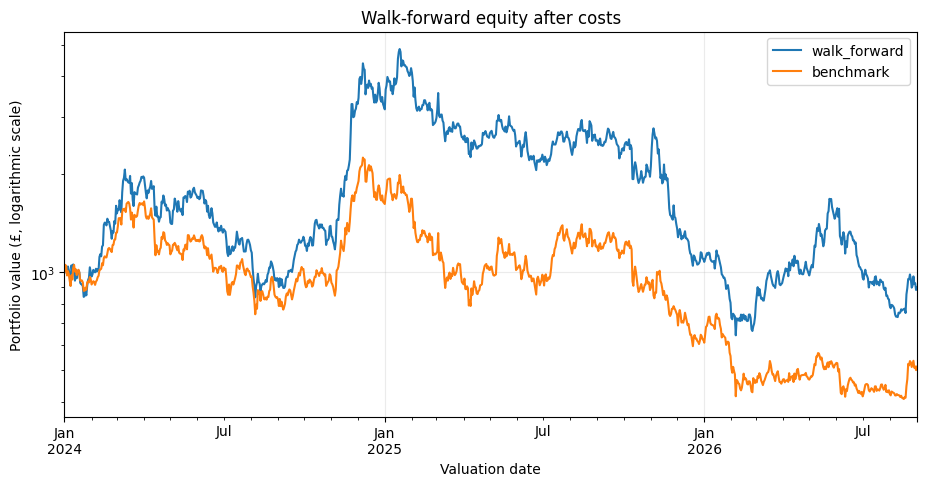

In [46]:
import matplotlib.pyplot as plt

equity = pd.DataFrame({
    name: ledger.set_index("valuation_at")["equity_close_gbp"]
    for name, (ledger, trades, positions) in walk_forward_runs.items()
})

initial = pd.DataFrame(
    1000.0,
    index=[pd.Timestamp(WEEKLY_PROTOCOL["oos_start"], tz="UTC")],
    columns=equity.columns,
)
equity = pd.concat([initial, equity]).sort_index()

ax = equity.plot(figsize=(11, 5), logy=True)
ax.set(
    title="Walk-forward equity after costs",
    xlabel="Valuation date",
    ylabel="Portfolio value (£, logarithmic scale)",
)
ax.grid(alpha=0.25)
plt.show()

In [47]:
import inference
importlib.reload(inference)

edge_test, bootstrap_draws = inference.test_walk_forward_edge(
    walk_forward_runs, WEEKLY_PROTOCOL
)

display(
    edge_test[["sharpe_difference", "ci_lower", "ci_upper"]]
    .round(3)
)

,sharpe_difference,ci_lower,ci_upper
block_days,,,
28.0,0.347,-0.359,1.004
14.0,0.347,-0.323,0.987
56.0,0.347,-0.409,1.020
